<a href="https://colab.research.google.com/github/raissabarb/cn/blob/main/Atividade_1_Raissa_e_Isabela_Entrega_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integrantes:

*   Isabela Cristina (Exercício B, C, E);
*   Raissa Barbosa (Exercício A, D, Gif, E)

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# Gif e quadro
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
from PIL import Image as PILImage

plt.style.use("seaborn-v0_8-whitegrid")

# **Parte A – truncamento e arredondamento**

In [2]:
# 1 e 2

def truncarNum(numero, casas):
    fator = 10**casas
    return math.trunc(numero * fator) / fator


def arredondarNum(numero, casas):
    num_arr = round(numero, casas)
    return num_arr


def erroAbsoluto(referencia, aproximacao):
    erro = abs(referencia - aproximacao)
    return erro


def erroRelativo(referencia, aproximacao):
    if abs(referencia) == 0:
        return "Indefinido"
    else:
        ea = erroAbsoluto(referencia, aproximacao)
        erro = ea / abs(referencia)
        return erro


def erroPercentual(erroR):
    if erroR == "Indefinido":
        return "Indefinido"
    else:
        erro = erroR * 100
        return erro


valores = {"x1": 3.14159265, "x2": 98.76543, "x3": 0.00498765}
casas_decimais = [0, 1, 2, 3, 4]

dados_tabela = [] # para tabela
resultados_ea = {nome: {"truncado": [], "arredondado": []} for nome in valores} # para gráfico

for n in casas_decimais:
    print(f"\n*** n = {n}***")
    for nome, x in valores.items():
        x_truncado = truncarNum(x, n)
        x_arr = arredondarNum(x, n)

        ea_t = erroAbsoluto(x, x_truncado)
        ea_a = erroAbsoluto(x, x_arr)

        er_t = erroRelativo(x, x_truncado)
        er_a = erroRelativo(x, x_arr)

        ep_t = erroPercentual(er_t)
        ep_a = erroPercentual(er_a)

        # tabela
        dados_tabela.append([n, "Truncado", x, f"{x_truncado:.{n}f}", f"{ea_t:.6e}", f"{er_t:.6e}", f"{ep_t:.2f}%"])
        dados_tabela.append([n, "Arredondado", x, f"{x_arr:.{n}f}", f"{ea_a:.6e}", f"{er_a:.6e}", f"{ep_a:.2f}%"])

        # gráfico
        resultados_ea[nome]["truncado"].append(ea_t)
        resultados_ea[nome]["arredondado"].append(ea_a)

        print(f"Truncado = {x_truncado:.{n}f} (Ea={ea_t:.2e}) --- "f"Arredondado = {x_arr:.{n}f} (Ea={ea_a:.2e})")



*** n = 0***
Truncado = 3 (Ea=1.42e-01) --- Arredondado = 3 (Ea=1.42e-01)
Truncado = 98 (Ea=7.65e-01) --- Arredondado = 99 (Ea=2.35e-01)
Truncado = 0 (Ea=4.99e-03) --- Arredondado = 0 (Ea=4.99e-03)

*** n = 1***
Truncado = 3.1 (Ea=4.16e-02) --- Arredondado = 3.1 (Ea=4.16e-02)
Truncado = 98.7 (Ea=6.54e-02) --- Arredondado = 98.8 (Ea=3.46e-02)
Truncado = 0.0 (Ea=4.99e-03) --- Arredondado = 0.0 (Ea=4.99e-03)

*** n = 2***
Truncado = 3.14 (Ea=1.59e-03) --- Arredondado = 3.14 (Ea=1.59e-03)
Truncado = 98.76 (Ea=5.43e-03) --- Arredondado = 98.77 (Ea=4.57e-03)
Truncado = 0.00 (Ea=4.99e-03) --- Arredondado = 0.00 (Ea=4.99e-03)

*** n = 3***
Truncado = 3.141 (Ea=5.93e-04) --- Arredondado = 3.142 (Ea=4.07e-04)
Truncado = 98.765 (Ea=4.30e-04) --- Arredondado = 98.765 (Ea=4.30e-04)
Truncado = 0.004 (Ea=9.88e-04) --- Arredondado = 0.005 (Ea=1.24e-05)

*** n = 4***
Truncado = 3.1415 (Ea=9.27e-05) --- Arredondado = 3.1416 (Ea=7.35e-06)
Truncado = 98.7654 (Ea=3.00e-05) --- Arredondado = 98.7654 (Ea=3.

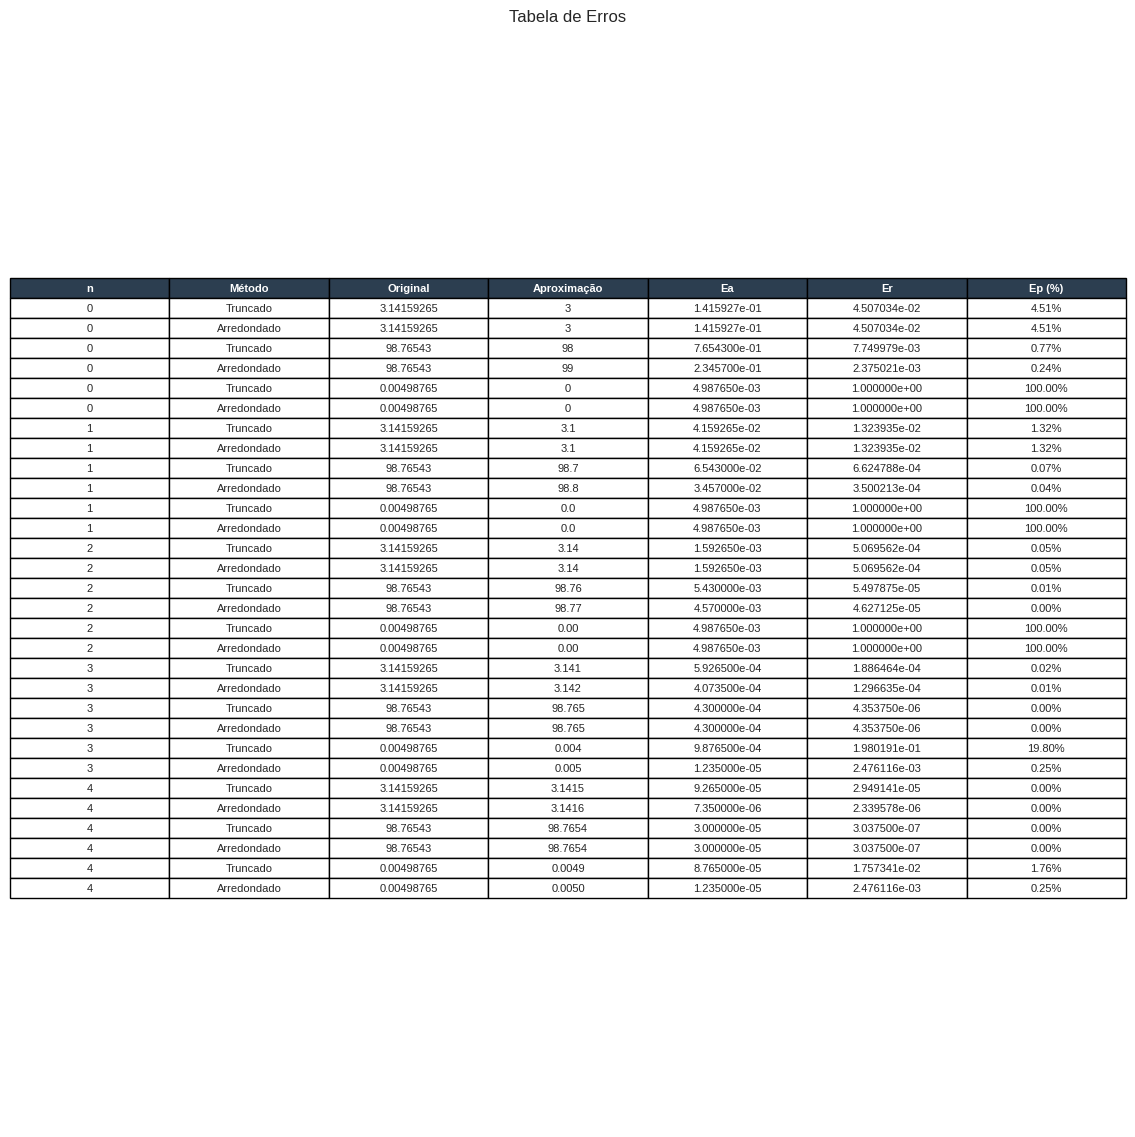

In [3]:
# 3

colunas = ["n", "Método", "Original", "Aproximação", "Ea", "Er", "Ep (%)"]

fig, ax = plt.subplots(figsize=(12, 14))
ax.axis("off")

tabela = ax.table(cellText=dados_tabela, colLabels=colunas, loc="center", cellLoc="center")

tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.scale(1.2, 1.2)

for (i, j), val in tabela.get_celld().items():
    if i == 0:
        val.set_facecolor("#2c3e50")
        val.get_text().set_color("white")
        val.get_text().set_weight("bold")

plt.title("Tabela de Erros", fontsize=12, pad=20)
plt.show()

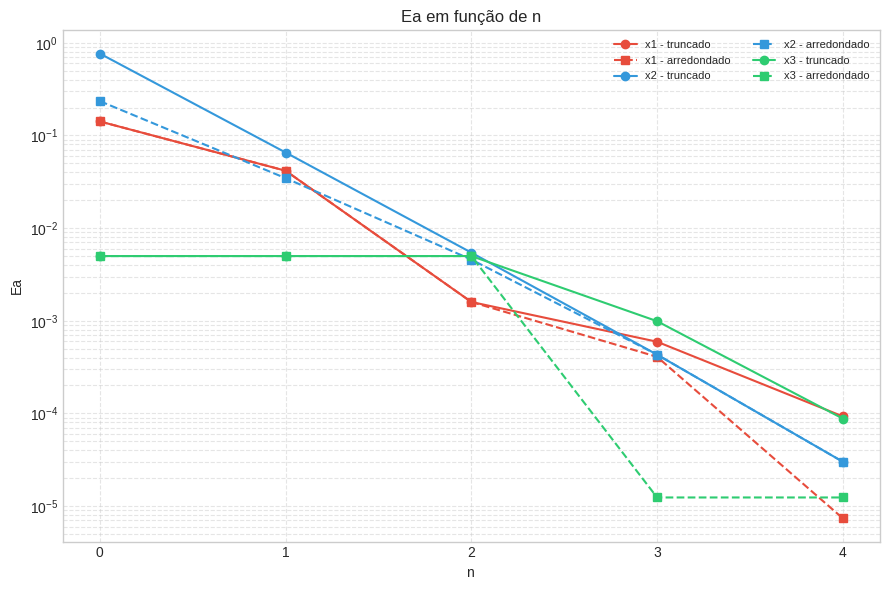

In [4]:
# 4

fig, ax = plt.subplots(figsize=(9, 6))

cores = {"x1": "#e74c3c", "x2": "#3498db", "x3": "#2ecc71"}

for nome in valores:
    ax.plot(casas_decimais, resultados_ea[nome]["truncado"], marker="o", linestyle="-", color=cores[nome], label=f"{nome} - truncado")
    ax.plot(casas_decimais, resultados_ea[nome]["arredondado"], marker="s", linestyle="--", color=cores[nome], label=f"{nome} - arredondado")

ax.set_yscale("log")
ax.set_xlabel("n")
ax.set_ylabel("Ea")
ax.set_xticks(range(min(casas_decimais), max(casas_decimais) + 1))
ax.set_title("Ea em função de n")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

5. Sim, o arredondamento sempre gera erros menores ou iguais aos do truncamento, como foi possível observar na tabela criada, cujos erros de arredondamento sempre ficaram, no máximo, iguais aos erros de truncamento. Isso acontece porque o truncamento não leva em consideração a casa decimal após o limite de corte, o que pode prejudicar um resultado. Isso acontece de forma bastante significativa para números muito pequenos e com muitas casas decimais, como foi o caso do x3 para n=3, onde o erro percentual saiu de menos de 1% e foi para quase 20% com o truncamento.

# **Parte B – medidas de pressão arterial**

In [5]:
#4 B.01 ------------------------------------------------------------------------------------------

#valores originais
pressao_arterial = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

pa_media = np.mean(pressao_arterial)

#valores arredondados para o inteiro mais proximo
pressao_arterial_int = np.round(pressao_arterial)
print(pressao_arterial_int)

#valores truncados para numero inteiro
pressao_arterial_trunc = np.trunc(pressao_arterial)
print(pressao_arterial_trunc)

def estatisticas(serie,nome):
    media = np.mean(serie)
    minimo = min(serie)
    maximo = max(serie)
    desvio_padrao = np.std(serie, ddof=1) #o segundo argumento é pq é amostral. (divisor n-1). Sem ele, é desvio populacional
    amplitude = maximo - minimo
    return {
        "nome": nome,
        "media": media,
        "minimo": minimo,
        "maximo": maximo,
        "desvio_padrao": desvio_padrao,
        "amplitude": amplitude
    }

def erros(valor_ref, valor_aprox):
    erro_absoluto = abs(valor_ref - valor_aprox) # calcula a distância entre o valor de referência e a aproximação
    erro_relativo = erro_absoluto / abs(valor_ref) # divide o erro absoluto pelo módulo do valor de referência
    erro_percentual = erro_relativo * 100.0 # multiplica o erro relativo por 100
    return erro_absoluto, erro_relativo, erro_percentual


stat_original = estatisticas(pressao_arterial, "Original")
stat_arredondado = estatisticas(pressao_arterial_int, "Arredondado")
stat_truncado = estatisticas(pressao_arterial_trunc, "Truncado")

tbl_estatisticas = pd.DataFrame([stat_original, stat_arredondado, stat_truncado])
print("Estatísticas")
display(tbl_estatisticas)

ea_int, er_int, ep_int = erros(stat_arredondado["media"], pa_media)
ea_trunc, er_trunc, ep_trunc = erros(stat_truncado["media"], pa_media)

tabela_erros = pd.DataFrame([
    {"Série": "Arredondada", "Erro Absoluto": ea_int, "Erro Relativo": er_int, "Erro %": ep_int},
    {"Série": "Truncada",    "Erro Absoluto": ea_trunc, "Erro Relativo": er_trunc, "Erro %": ep_trunc},
])
print("\nErros")
display(tabela_erros)

pa_media_ref = pa_media
ea_B_arred, er_B_arred, ep_B_arred = ea_int, er_int, ep_int
ea_B_trunc, er_B_trunc, ep_B_trunc = ea_trunc, er_trunc, ep_trunc

[122. 120. 122. 120. 121. 121. 122. 121. 120. 122.]
[121. 120. 122. 119. 121. 120. 122. 121. 120. 121.]
Estatísticas


,nome,media,minimo,maximo,desvio_padrao,amplitude
0,Original,121.12,119.8,122.4,0.833733,2.6
1,Arredondado,121.10,120.0,122.0,0.875595,2.0
2,Truncado,120.70,119.0,122.0,0.948683,3.0



Erros


,Série,Erro Absoluto,Erro Relativo,Erro %
0,Arredondada,0.02,0.000165,0.016515
1,Truncada,0.42,0.003480,0.347970


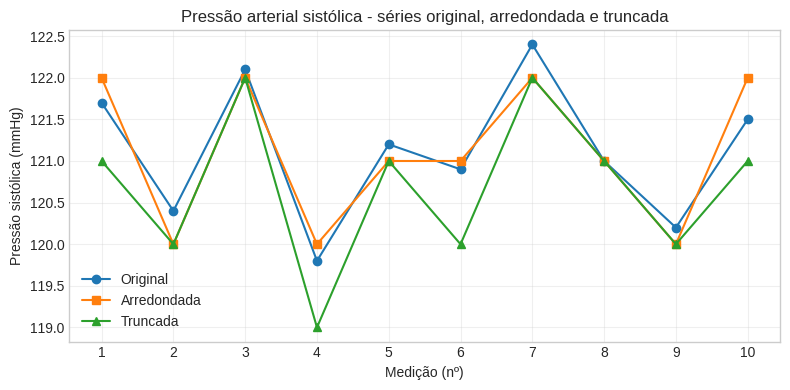

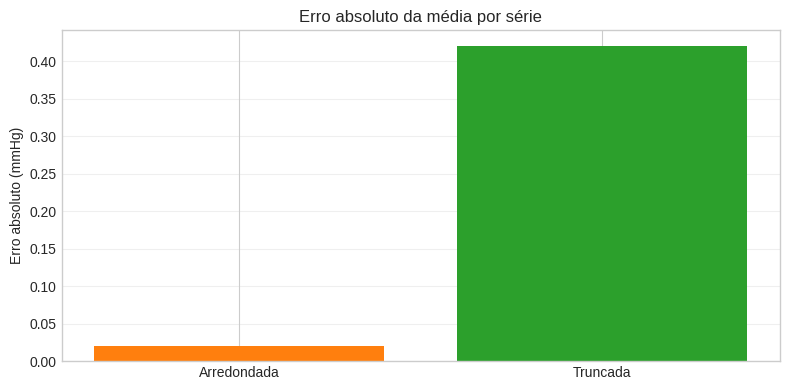

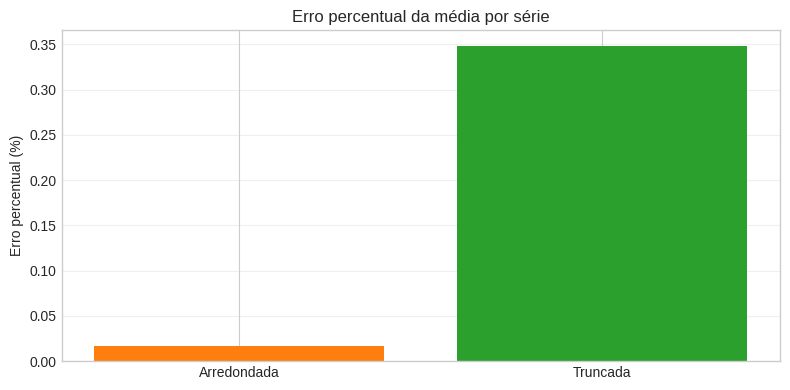

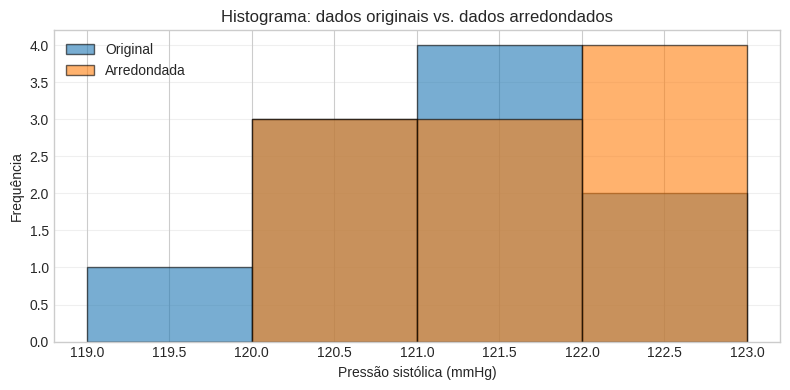

In [6]:
# 4 B.02 ------------------------------------------------------------------------------------------

#indices = np.arange(1, 11)  #numeração das 10 medições (1 a 10)
indices = np.linspace(1.0, 10.0, 10) #tb faz numeração das 10 medições (1 a 10)

# --- Gráfico 1 - 3 series com as 10 medições ---
plt.figure(figsize=(8, 4))
plt.plot(indices, pressao_arterial, marker='o', label='Original')
plt.plot(indices, pressao_arterial_int, marker='s', label='Arredondada')
plt.plot(indices, pressao_arterial_trunc, marker='^', label='Truncada')
plt.xlabel('Medição (nº)')
plt.ylabel('Pressão sistólica (mmHg)')
plt.title('Pressão arterial sistólica - séries original, arredondada e truncada')
plt.xticks(indices) #mostra valores exatos de x
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_medicoes.png', dpi=150)
plt.show()

# --- Gráfico 2: erros absolutos das médias ---
plt.figure(figsize=(8, 4))
series_nomes = ['Arredondada', 'Truncada']
erros_absolutos = [ea_int, ea_trunc]
plt.bar(series_nomes, erros_absolutos, color=['tab:orange', 'tab:green']) #grafico de barras
plt.ylabel('Erro absoluto (mmHg)')
plt.title('Erro absoluto da média por série')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout() #ajusta o espaçamento entre os componentes do grafico
plt.savefig('grafico_erro_absoluto.png', dpi=150)
plt.show()

# --- Gráfico 3: erros percentuais das médias ---
plt.figure(figsize=(8, 4))
erros_percentuais = [ep_int, ep_trunc]
plt.bar(series_nomes, erros_percentuais, color=['tab:orange', 'tab:green'])
plt.ylabel('Erro percentual (%)')
plt.title('Erro percentual da média por série')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_erro_percentual.png', dpi=150)
plt.show()

# --- Gráfico 4: histograma dos dados originais e dos dados inteiros arredondados ---
plt.figure(figsize=(8, 4))
bins = np.arange(119, 124, 1)  # faixas de 1 mmHg cobrindo o intervalo dos dados
plt.hist(pressao_arterial, bins=bins, alpha=0.6, label='Original', edgecolor='black')
plt.hist(pressao_arterial_int, bins=bins, alpha=0.6, label='Arredondada', edgecolor='black')
plt.xlabel('Pressão sistólica (mmHg)')
plt.ylabel('Frequência')
plt.title('Histograma: dados originais vs. dados arredondados')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma.png', dpi=150)
plt.show()

***Explique se a representação inteira é suficiente para preservar a média e a variabilidade desta pequena amostra:***

Diante da amostra apresentada, acreditamos que sim. A representação inteira demonstrou ser mais fiel do que a representação truncada, com um erro absoluto de 0.02 mmHg, equivalente a 0.01% da escala do problema. A média se manteve praticamente igual ao descartar as casas decimais, e a amplitude teve uma diferença de 0.6. Claro que a resposta final depende da tolerância desejada, mas, de modo superficial, o grupo considera que a média e a variabilidade foram bem representadas.

# **Parte C - vazão em um tubo de pequeno diâmetro**

In [19]:

# 5 C.01 ------------------------------------------------------------------------------------------

#definindo função para auxiliar nos multiplos calculos
def calcular_Q(r_m, dp, mu, L):
    return (np.pi * r_m**4 * dp) / (8 * mu * L)

r_mm_ref = 0.80          # raio em mm
L_ref    = 0.20          # comprimento em metros
mu_ref   = 3.5e-3        # viscosidade em Pa
dp_ref   = 1200.0        # diferença de pressao em Pa

r_m_ref = r_mm_ref / 1000.0     #convertendo raio de mm pra metros

Q_ref = calcular_Q(r_m_ref, dp_ref, mu_ref, L_ref)

Q_cenario_1 = Q_ref


# 5 C.02 ------------------------------------------------------------------------------------------

#mais funcoes auxiliares
def truncar(x, n):
    fator = 10.0**n
    return np.trunc(x * fator) / fator

def arredondar(x, n):
    return np.round(x, n)


# r arredondado e truncado para 1 casa decimal em mm
r_mm_arred = arredondar(r_mm_ref, 1)
r_mm_trunc = truncar(r_mm_ref, 1)
Q_r_arred = calcular_Q(r_mm_arred / 1000.0, dp_ref, mu_ref, L_ref)
Q_r_trunc = calcular_Q(r_mm_trunc / 1000.0, dp_ref, mu_ref, L_ref)


# 5 C.03 ------------------------------------------------------------------------------------------
# µ arredondada e truncada para 3 casas decimais em Pa·s
mu_arred = arredondar(mu_ref, 3)
mu_trunc = truncar(mu_ref, 3)
Q_mu_arred = calcular_Q(r_m_ref, dp_ref, mu_arred, L_ref)
Q_mu_trunc = calcular_Q(r_m_ref, dp_ref, mu_trunc, L_ref)


# 5 C.04 ------------------------------------------------------------------------------------------
dp_arred = arredondar(dp_ref, -2)
dp_trunc = truncar(dp_ref, -2)
Q_dp_arred = calcular_Q(r_m_ref, dp_arred, mu_ref, L_ref)
Q_dp_trunc = calcular_Q(r_m_ref, dp_trunc, mu_ref, L_ref)

# 5 C.05 ------------------------------------------------------------------------------------------
Q_todos_arred = calcular_Q(r_mm_arred / 1000.0, dp_arred, mu_arred, L_ref)  #convertendo r pra metros
Q_todos_trunc = calcular_Q(r_mm_trunc / 1000.0, dp_trunc, mu_trunc, L_ref)


# 5 C.1 TABELA FINAL ------------------------------------------------------------------------------

# montando tabela para mostrar resultados de 5 C.01 até 5 C.05
cenarios = {
    "Referência (todos exatos)":        Q_cenario_1,
    "r arredondado (1 casa)":           Q_r_arred,
    "r truncado (1 casa)":              Q_r_trunc,
    "µ arredondada (3 casas)":          Q_mu_arred,
    "µ truncada (3 casas)":             Q_mu_trunc,
    "Δp arredondada (centena)":         Q_dp_arred,
    "Δp truncada (centena)":            Q_dp_trunc,
    "Todas arredondadas":               Q_todos_arred,
    "Todas truncadas":                  Q_todos_trunc,
}

linhas = []
for nome, Q_aprox in cenarios.items():
    ea, er, ep = erros(Q_aprox, Q_ref)
    linhas.append({
        "Cenário": nome,
        "Q (m³/s)": Q_aprox,
        "Erro absoluto (m³/s)": ea,
        "Erro relativo": er,
        "Erro percentual (%)": ep
    })

tabela_C1 = pd.DataFrame(linhas)
print("Tabela C.1 - Vazão e erros para os diferentes cenários de aproximação")
display(tabela_C1)

# guardando pra parte E
ea_vazao_arred, er_vazao_arred, ep_vazao_arred = erros(Q_todos_arred,Q_ref)
ea_vazao_trunc, er_vazao_trunc, ep_vazao_trunc = erros(Q_todos_trunc,Q_ref)


Tabela C.1 - Vazão e erros para os diferentes cenários de aproximação


,Cenário,Q (m³/s),Erro absoluto (m³/s),Erro relativo,Erro percentual (%)
0,Referência (todos exatos),2.757421e-07,0.000000e+00,0.000000,0.000000
1,r arredondado (1 casa),2.757421e-07,0.000000e+00,0.000000,0.000000
2,r truncado (1 casa),2.757421e-07,0.000000e+00,0.000000,0.000000
3,µ arredondada (3 casas),2.412743e-07,3.446776e-08,0.142857,14.285714
4,µ truncada (3 casas),3.216991e-07,4.595701e-08,0.142857,14.285714
5,Δp arredondada (centena),2.757421e-07,0.000000e+00,0.000000,0.000000
6,Δp truncada (centena),2.757421e-07,0.000000e+00,0.000000,0.000000
7,Todas arredondadas,2.412743e-07,3.446776e-08,0.142857,14.285714
8,Todas truncadas,3.216991e-07,4.595701e-08,0.142857,14.285714


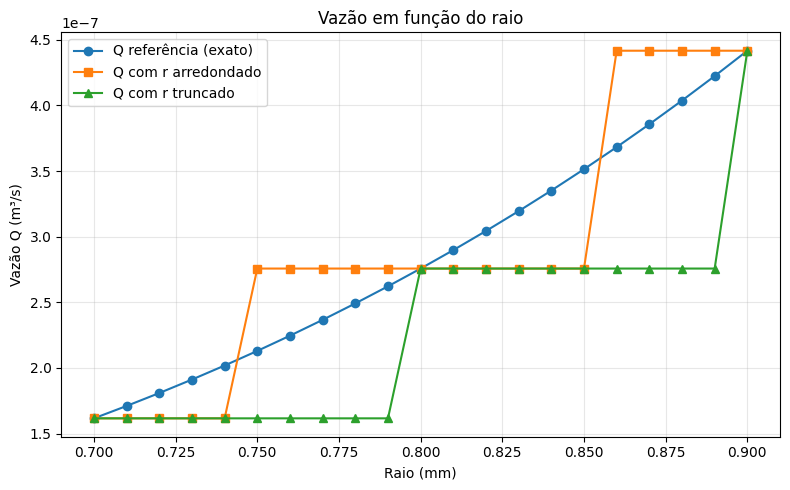

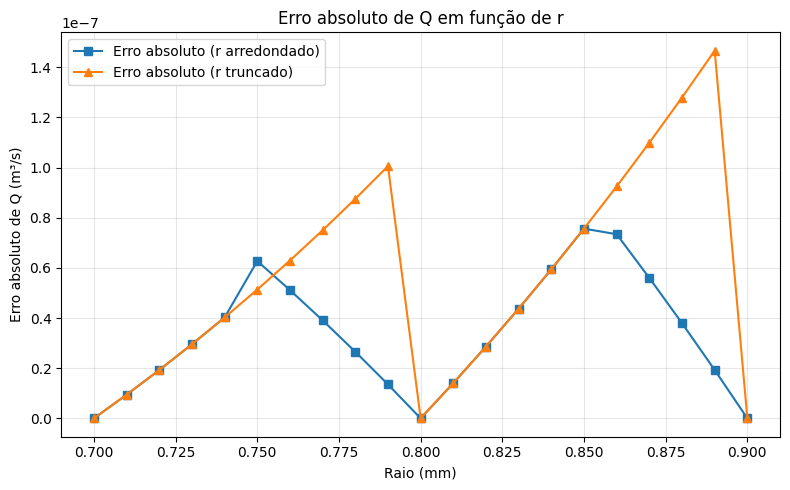

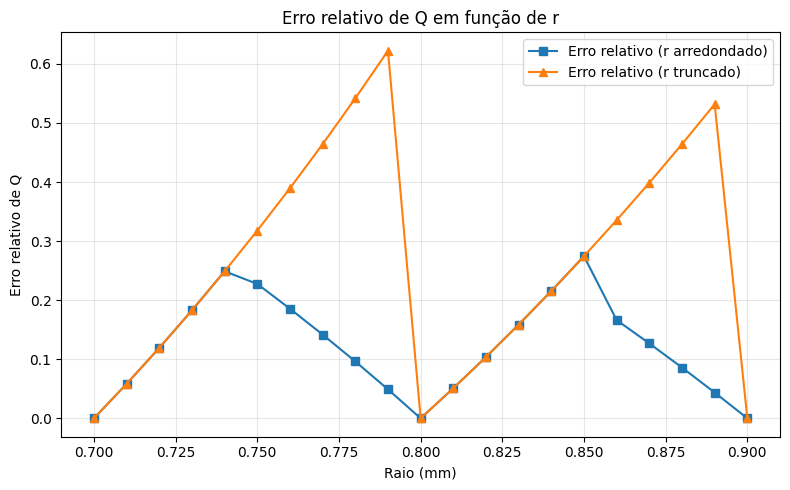

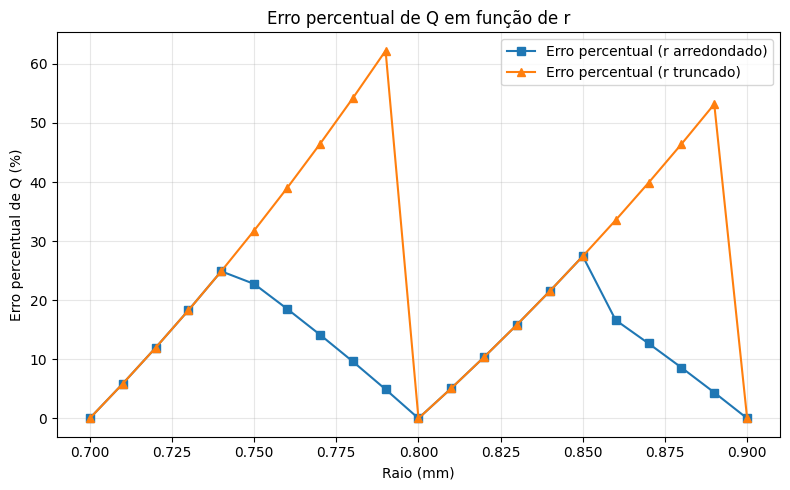

In [20]:

# 5 C.2 Sensibilidade -----------------------------------------------------------------------------

# vetor de raios variando com intervalos de 0.01 mm
r_mm_vetor = np.linspace(0.70, 0.90, 21)

# arredondar e truncar os vetores de raio em 1 casa decimal para os calculos a seguir
r_mm_vetor_arred = arredondar(r_mm_vetor, 1)
r_mm_vetor_trunc = truncar(r_mm_vetor, 1)

# agora, calcular Q para os 3 casos
Q_referencia = calcular_Q(r_mm_vetor / 1000.0, dp_ref, mu_ref, L_ref)
Q_arredondado = calcular_Q(r_mm_vetor_arred / 1000.0, dp_ref, mu_ref, L_ref)
Q_truncado = calcular_Q(r_mm_vetor_trunc / 1000.0, dp_ref, mu_ref, L_ref)

# calcular os erros
ea_arred, er_arred, ep_arred = erros(Q_arredondado, Q_referencia)
ea_trunc, er_trunc, ep_trunc = erros(Q_truncado, Q_referencia)


# 5 C.2.01 Grafico --------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(r_mm_vetor, Q_referencia, label='Q referência (exato)', marker='o')
plt.plot(r_mm_vetor, Q_arredondado, label='Q com r arredondado', marker='s')
plt.plot(r_mm_vetor, Q_truncado, label='Q com r truncado', marker='^')
plt.xlabel('Raio (mm)')
plt.ylabel('Vazão Q (m³/s)')
plt.title('Vazão em função do raio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C2_Q_vs_r.png', dpi=150)
plt.show()
print("\n")

# 5 C.2.02 Grafico erro absoluto ------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(r_mm_vetor, ea_arred, label='Erro absoluto (r arredondado)', marker='s')
plt.plot(r_mm_vetor, ea_trunc, label='Erro absoluto (r truncado)', marker='^')
plt.xlabel('Raio (mm)')
plt.ylabel('Erro absoluto de Q (m³/s)')
plt.title('Erro absoluto de Q em função de r')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C2_erro_absoluto.png', dpi=150)
plt.show()
print("\n")

# 5 C.2.03 Grafico erro relativo ------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(r_mm_vetor, er_arred, label='Erro relativo (r arredondado)', marker='s')
plt.plot(r_mm_vetor, er_trunc, label='Erro relativo (r truncado)', marker='^')
plt.xlabel('Raio (mm)')
plt.ylabel('Erro relativo de Q')
plt.title('Erro relativo de Q em função de r')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C2_erro_relativo.png', dpi=150)
plt.show()
print("\n")

# 5 C.2.04 Grafico erro percentual ----------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(r_mm_vetor, ep_arred, label='Erro percentual (r arredondado)', marker='s')
plt.plot(r_mm_vetor, ep_trunc, label='Erro percentual (r truncado)', marker='^')
plt.xlabel('Raio (mm)')
plt.ylabel('Erro percentual de Q (%)')
plt.title('Erro percentual de Q em função de r')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C2_erro_percentual.png', dpi=150)
plt.show()
print("\n")


***Explique por que o erro no raio é amplificado na vazão:***
Como visto em sala durante a aula 3, se os dados de entrada contém pequenas incertezas, as operações propagam essa incerteza. Em produtos e potências, o erro pode crescer rapidamente. Como a vazão é proporcional à quarta potência do raio, pequenas incertezas no raio são elevadas à potência 4, ampliando significativamente o erro na vazão.

# **Parte D - escoamento em um nanocateter**

Text(0.5, 1.0, 'Erros para cada Δr (0,1 a 5,0 nm)')

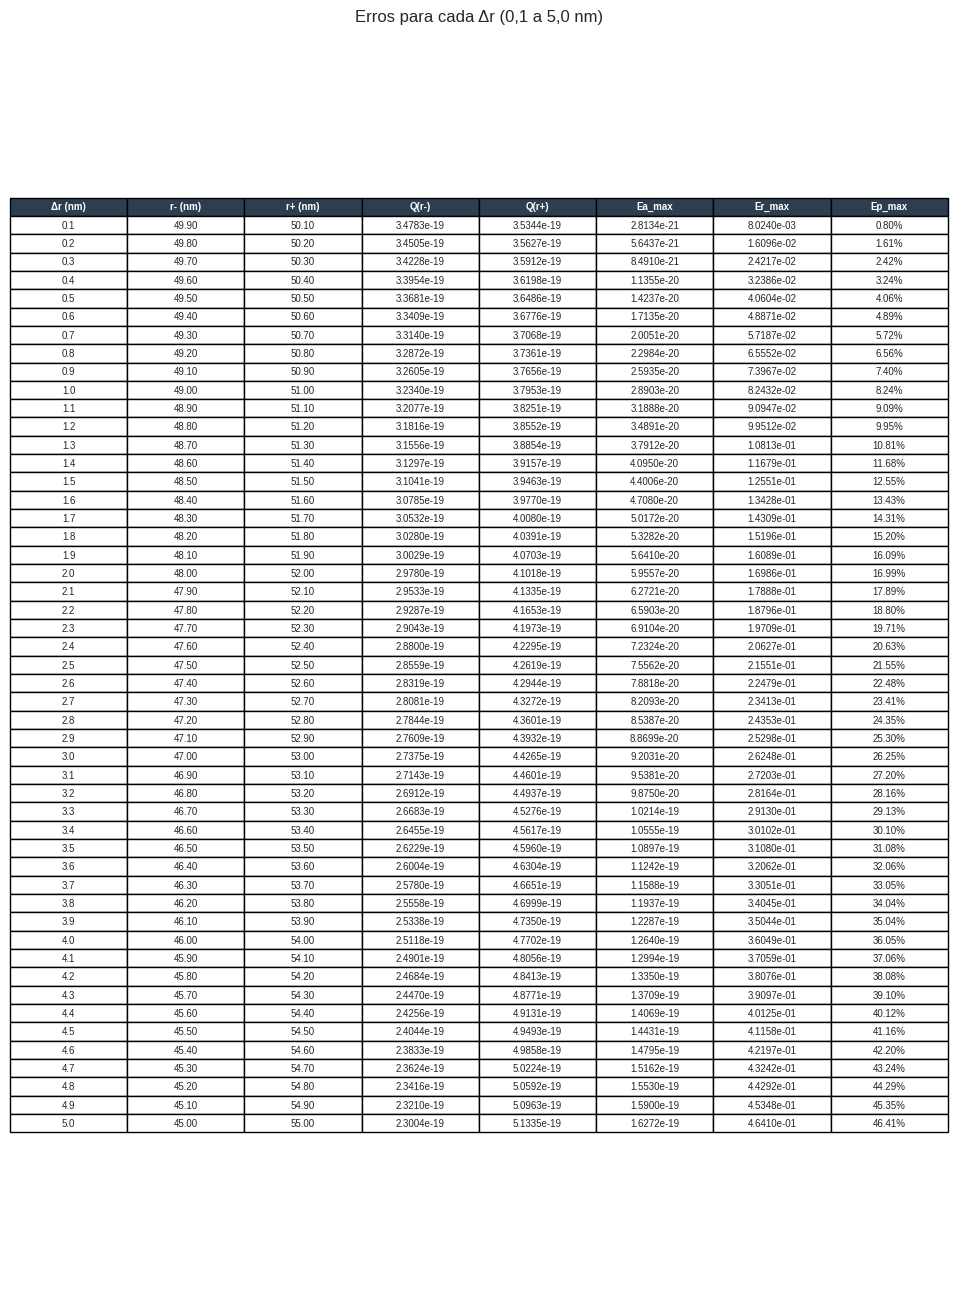

In [9]:
# D1

r = 50e-9
L = 10e-6
mu = 3.5e-3
dp = 5000.0

def vazao_hagen_poiseuille(raio, delta_p, viscosidade, comprimento):
    Q = (np.pi * raio**4 * delta_p) / (8 * viscosidade * comprimento)
    return Q


delta_r_nm = np.arange(0.1, 5.0 + 0.05, 0.1)
delta_r_m = delta_r_nm * 1e-9

Q_r = vazao_hagen_poiseuille(r, dp, mu, L) # valor de referência
r_menos = r - delta_r_m
r_mais  = r + delta_r_m

Q_menos = vazao_hagen_poiseuille(r_menos, dp, mu, L)
Q_mais  = vazao_hagen_poiseuille(r_mais, dp, mu, L)

# erro absoluto
Ea_menos = np.abs(Q_r - Q_menos)
Ea_mais  = np.abs(Q_r - Q_mais)
Ea_max   = np.maximum(Ea_menos, Ea_mais)

# erro relativo e percentual
Er_max = Ea_max / Q_r
Ep_max = 100 * Er_max

# aproximação linear
Er_aprox_linear = 4 * delta_r_m / r

# erros
dados_tabela_D1 = []
for i in range(len(delta_r_nm)):
    dados_tabela_D1.append([f"{delta_r_nm[i]:.1f}", f"{r_menos[i]*1e9:.2f}", f"{r_mais[i]*1e9:.2f}", f"{Q_menos[i]:.4e}",
                            f"{Q_mais[i]:.4e}", f"{Ea_max[i]:.4e}", f"{Er_max[i]:.4e}", f"{Ep_max[i]:.2f}%"])

colunas_D1 = ["Δr (nm)", "r- (nm)", "r+ (nm)", "Q(r-)", "Q(r+)", "Ea_max", "Er_max", "Ep_max"]

fig, ax = plt.subplots(figsize=(11, 16))

ax.axis("off")
tabela = ax.table(cellText=dados_tabela_D1, colLabels=colunas_D1, loc="center", cellLoc="center")
tabela.auto_set_font_size(False)
tabela.set_fontsize(7)
tabela.scale(1.1, 1.1)

for (i, j), val in tabela.get_celld().items():
    if i == 0:
        val.set_facecolor("#2c3e50")
        val.get_text().set_color("white")
        val.get_text().set_weight("bold")

plt.title("Erros para cada Δr (0,1 a 5,0 nm)", fontsize=12, pad=20)

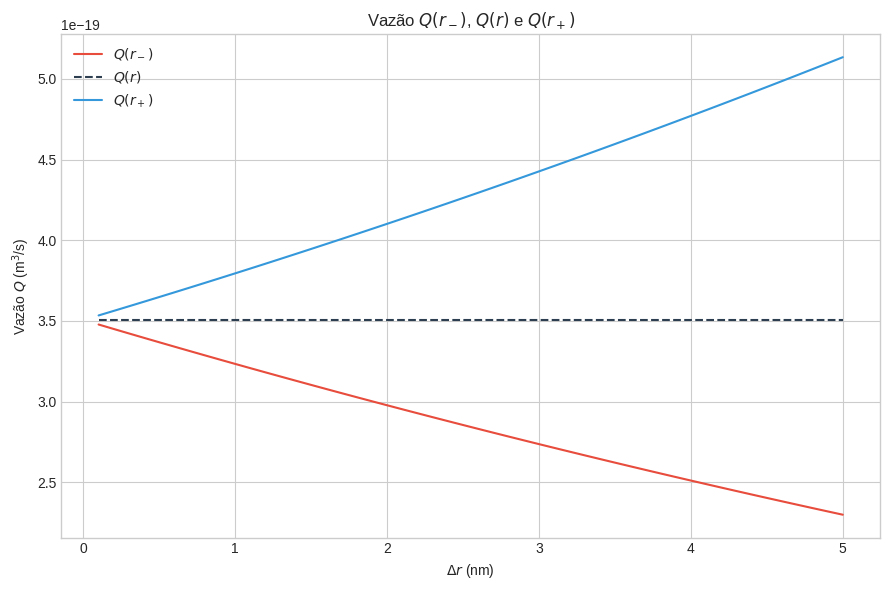

In [10]:
# 1

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(delta_r_nm, Q_menos, label=r"$Q(r_-)$", color="#e74c3c")
ax.plot(delta_r_nm, np.full_like(delta_r_nm, Q_r), label=r"$Q(r)$", color="#2c3e50", linestyle="--")
ax.plot(delta_r_nm, Q_mais, label=r"$Q(r_+)$", color="#3498db")

ax.set_xlabel(r"$\Delta r$ (nm)")
ax.set_ylabel(r"Vazão $Q$ (m$^3$/s)")
ax.set_title(r"Vazão $Q(r_-)$, $Q(r)$ e $Q(r_+)$")
ax.legend()

plt.tight_layout()
plt.show()

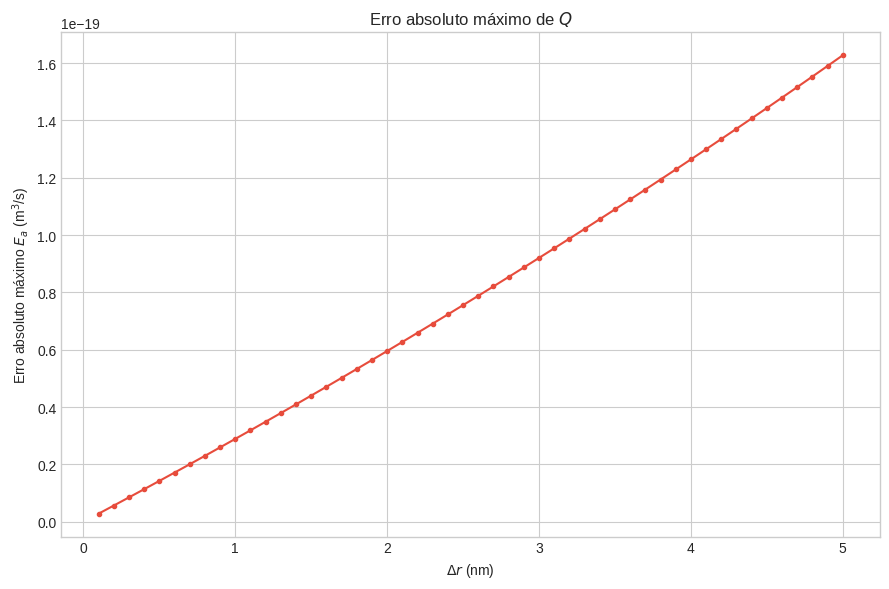

In [11]:
# 2

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(delta_r_nm, Ea_max, color="#e74c3c", marker="o", markersize=3)
ax.set_xlabel(r"$\Delta r$ (nm)")
ax.set_ylabel(r"Erro absoluto máximo $E_a$ (m$^3$/s)")
ax.set_title(r"Erro absoluto máximo de $Q$")

plt.tight_layout()
plt.show()

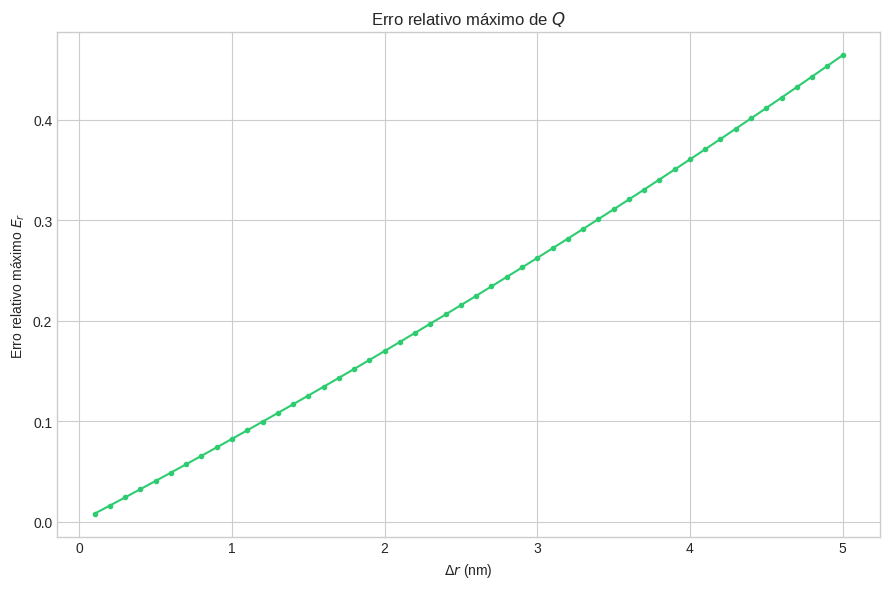

In [12]:
# 3

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(delta_r_nm, Er_max, color="#2ecc71", marker="o", markersize=3)
ax.set_xlabel(r"$\Delta r$ (nm)")
ax.set_ylabel(r"Erro relativo máximo $E_r$")
ax.set_title(r"Erro relativo máximo de $Q$")

plt.tight_layout()
plt.show()

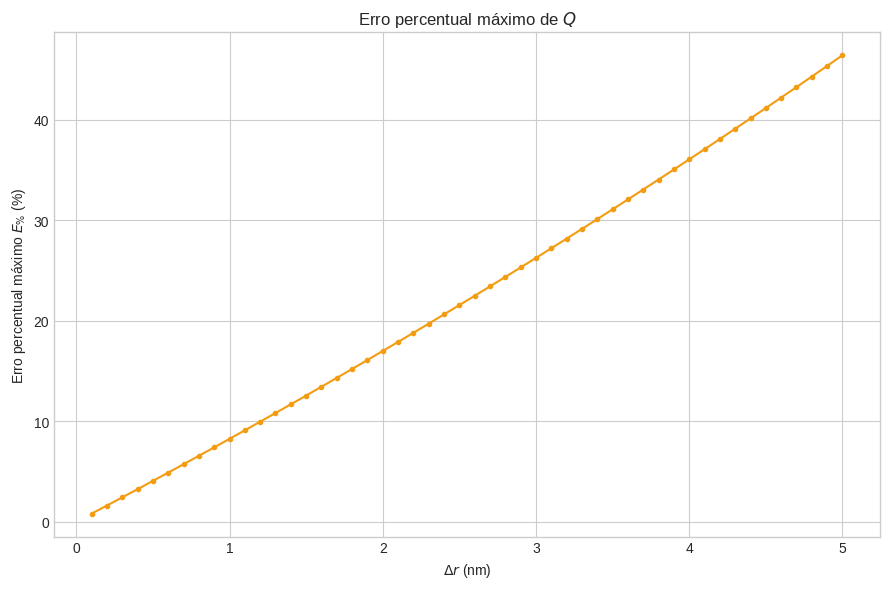

In [13]:
# 4

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(delta_r_nm, Ep_max, color="#f39c12", marker="o", markersize=3)
ax.set_xlabel(r"$\Delta r$ (nm)")
ax.set_ylabel(r"Erro percentual máximo $E_\%$ (%)")
ax.set_title(r"Erro percentual máximo de $Q$")

plt.tight_layout()
plt.show()

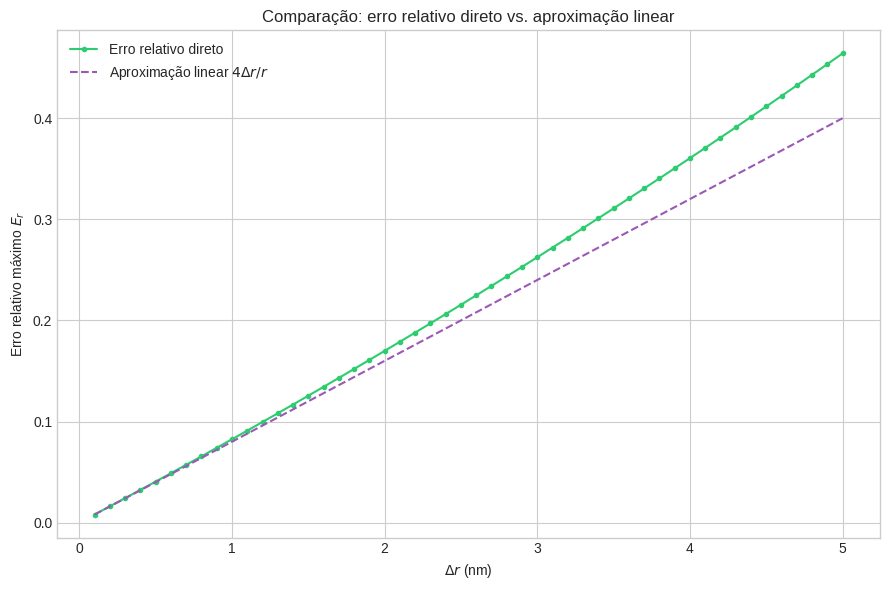

In [14]:
# final

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(delta_r_nm, Er_max, color="#2ecc71", marker="o", markersize=3, label="Erro relativo direto")
ax.plot(delta_r_nm, Er_aprox_linear, color="#9b59b6", linestyle="--", label=r"Aproximação linear $4\Delta r/r$")
ax.set_xlabel(r"$\Delta r$ (nm)")
ax.set_ylabel(r"Erro relativo máximo $E_r$")
ax.set_title(r"Comparação: erro relativo direto vs. aproximação linear")
ax.legend()

plt.tight_layout()
plt.show()

Ao comparar o erro direto com a aproximação linear, foi notado que ambos possuem valores próximos até um delta r de 1, porém quando a diferença de r cresce, percebemos que os valores se distanciam, com o erro chegando a quase 50% para delta r = 5, em comparação com os 40% da aproximação linear. Sendo assim, para grandes variações, podemos nos equivocar com o erro direto.

In [15]:
# D2

r_val = 50e-9
L_val = 10e-6
mu_val = 3.5e-3
dp_val = 5000.0

def calcular_r4_e_Q(dtype):
    r = dtype(r_val)
    L = dtype(L_val)
    mu = dtype(mu_val)
    dp = dtype(dp_val)
    pi = dtype(np.pi)

    r4 = r**4
    Q = (pi * r4 * dp) / (dtype(8) * mu * L)
    return r4, Q

r4_32, Q_32 = calcular_r4_e_Q(np.float32)
r4_64, Q_64 = calcular_r4_e_Q(np.float64)

diff_abs = abs(float(Q_64) - float(Q_32))
diff_rel = diff_abs / abs(float(Q_64))

eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps

print("*** Precisão computacional ***")

print("\n* float32\n")
print(f"r^4 (float32) = {r4_32!r}")
print(f"Q   (float32) = {Q_32!r}")

print("\n* float64\n")
print(f"Q   (float64) = {Q_64!r}")
print(f"r^4 (float64) = {r4_64!r}")

print("\n")
print(f"Diferença absoluta entre Q64 e Q32: {diff_abs:.6e}")
print(f"Diferença relativa entre Q64 e Q32: {diff_rel:.6e}")
print("\n")
print(f"np.finfo(float32).eps = {eps_32:.6e}")
print(f"np.finfo(float64).eps = {eps_64:.6e}")

*** Precisão computacional ***

* float32

r^4 (float32) = np.float32(6.2500004e-30)
Q   (float32) = np.float32(3.5062423e-19)

* float64

Q   (float64) = np.float64(3.506241800881465e-19)
r^4 (float64) = np.float64(6.249999999999999e-30)


Diferença absoluta entre Q64 e Q32: 5.228628e-26
Diferença relativa entre Q64 e Q32: 1.491234e-07


np.finfo(float32).eps = 1.192093e-07
np.finfo(float64).eps = 2.220446e-16


In [16]:
# final

def Q_de_r(raio, dtype):
    r_c = dtype(raio)
    L_c = dtype(L)
    mu_c = dtype(mu)
    dp_c = dtype(dp)
    return vazao_hagen_poiseuille(r_c, dp_c, mu_c, L_c)

def delta1(razao_dr_r, dtype):
    dr = dtype(razao_dr_r) * dtype(r)
    Q_r = Q_de_r(r, dtype)
    Q_r_mais_dr = Q_de_r(r + dr, dtype)
    return (Q_r_mais_dr - Q_r) / Q_r

def delta2(razao_dr_r, dtype):
    eps = dtype(razao_dr_r)
    return (dtype(1) + eps)**4 - dtype(1)

# valores de Delta_r/r progressivamente menores
razoes = np.logspace(-1, -12, 30)   # 0.1 -> 1e-12

d1_32 = np.array([float(delta1(e, np.float32)) for e in razoes])
d1_64 = np.array([float(delta1(e, np.float64)) for e in razoes])
d2_32 = np.array([float(delta2(e, np.float32)) for e in razoes])
d2_64 = np.array([float(delta2(e, np.float64)) for e in razoes])

# diferença absoluta entre delta1 e delta2
diff_32 = np.abs(d1_32 - d2_32)
diff_64 = np.abs(d1_64 - d2_64)

print("\n*** Comparação delta1 (direto) vs delta2 (fórmula fechada) ***\n")
print(f"{'Δr/r':>12} | {'δ1 float32':>14} | {'δ2 float32':>14} | {'δ1 float64':>16} | {'δ2 float64':>16}")
for i in range(0, len(razoes), 3):
    print(f"{razoes[i]:>12.2e} | {d1_32[i]:>14.6e} | {d2_32[i]:>14.6e} | {d1_64[i]:>16.6e} | {d2_64[i]:>16.6e}")


*** Comparação delta1 (direto) vs delta2 (fórmula fechada) ***

        Δr/r |     δ1 float32 |     δ2 float32 |       δ1 float64 |       δ2 float64
    1.00e-01 |   4.641001e-01 |   4.641001e-01 |     4.641000e-01 |     4.641000e-01
    7.28e-03 |   2.943523e-02 |   2.943516e-02 |     2.943526e-02 |     2.943526e-02
    5.30e-04 |   2.121037e-03 |   2.121210e-03 |     2.121012e-03 |     2.121012e-03
    3.86e-05 |   1.543042e-04 |   1.544952e-04 |     1.542737e-04 |     1.542737e-04
    2.81e-06 |   1.135348e-05 |   1.144409e-05 |     1.122891e-05 |     1.122891e-05
    2.04e-07 |   8.846871e-07 |   9.536743e-07 |     8.173441e-07 |     8.173441e-07
    1.49e-08 |   0.000000e+00 |   0.000000e+00 |     5.949409e-08 |     5.949409e-08
    1.08e-09 |   0.000000e+00 |   0.000000e+00 |     4.330547e-09 |     4.330547e-09
    7.88e-11 |   0.000000e+00 |   0.000000e+00 |     3.152184e-10 |     3.152181e-10
    5.74e-12 |   0.000000e+00 |   0.000000e+00 |     2.294437e-11 |     2.294431e-11


Para os maiores valores, ambos os deltas calculam bem, porém quando a variação fica muito pequena eles começam a se diferenciar. Para variações menores que 1,49^10-8, o float32  que só consegue armazenar até 7 dígitos, quando os números são muito parecidos a nível de se diferenciarem após essa quantidade de casas decimais, o float32 acaba os considerando iguais, zerando o delta.

3. Quando temos uma escala pequena num tubo, como é o caso do nanocateter em estudo, as influências que temos nos limiares das paredes se tornam muito mais presentes, já que grande parte do líquido que passa pelo cilindro está em contato com as paredes — ou seja, a razão superfície/volume aumenta conforme o tubo fica menor —, o que não ocorre para tubos maiores onde Hagen–Poiseuille é aplicado. O mesmo ocorre com o ponto da viscosidade. Logo, apesar de termos as contas realizadas de forma correta e com boa precisão numérica (como visto nos outros exercícios), essa fórmula foi pensada para tubos que não possuíam tanto líquido em contato com a superfície e cuja viscosidade não fosse tão significativa, portanto pode ser que Hagen–Poiseuille não seja a melhor escolha para esse caso: precisão no cálculo não garante que o modelo seja fisicamente adequado.

# **Parte E - síntese visual**

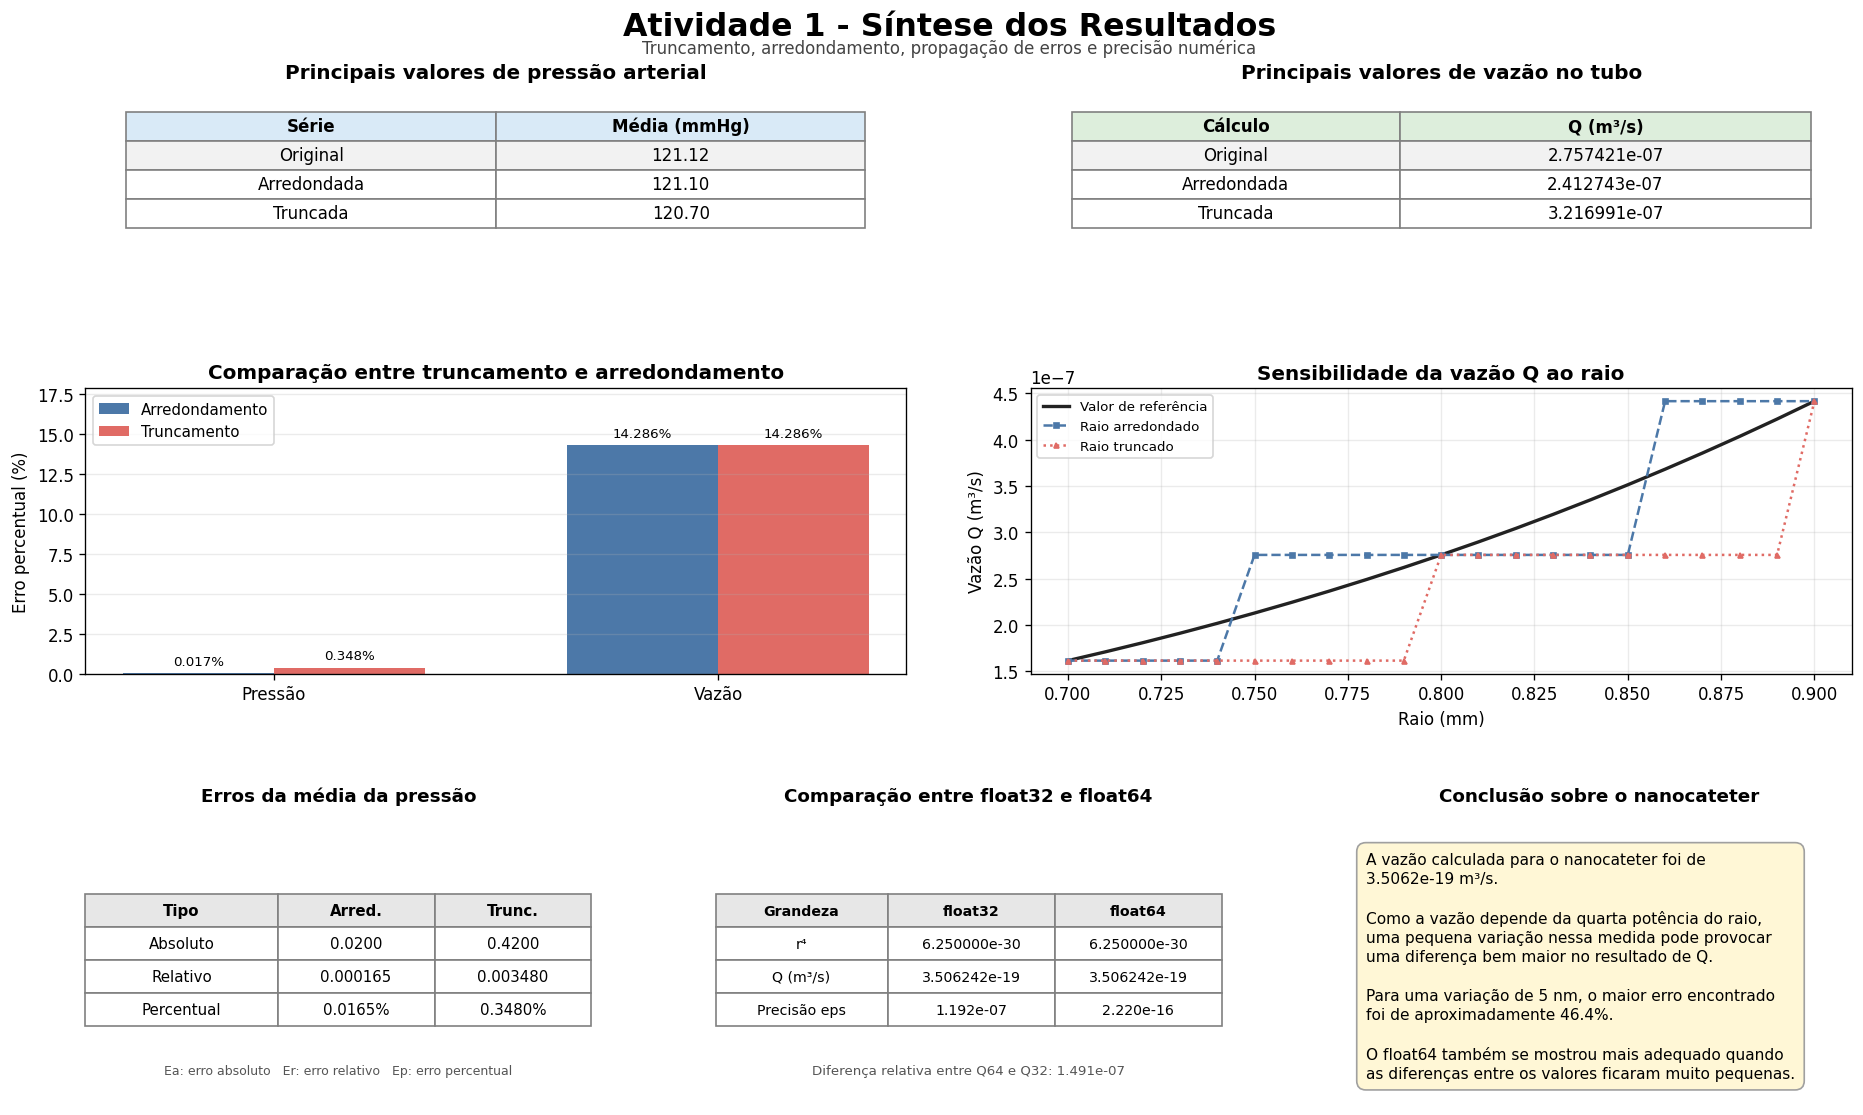

In [17]:
# Médias da pressão arterial calculadas na Parte B
pressao_original = stat_original["media"]
pressao_arredondada = stat_arredondado["media"]
pressao_truncada = stat_truncado["media"]

# Vazões calculadas na Parte C
# Q_cenario_1 representa o cálculo com os valores exatos
vazao_original = Q_cenario_1
vazao_arredondada = Q_todos_arred   #"todos" pq todos os parametros foram arredondados ou truncados
vazao_truncada = Q_todos_trunc

# Vazão de referência do nanocateter, calculada na Parte D
vazao_nanocateter = Q_r

# Maior erro percentual para uma variação de 5 nm
erro_maximo_nanocateter = Ep_max[-1]

# Erros da pressão - Calculado na parte B
ea_pressao_arred = ea_B_arred
er_pressao_arred = er_B_arred
ep_pressao_arred = ep_B_arred

ea_pressao_trunc = ea_B_trunc
er_pressao_trunc = er_B_trunc
ep_pressao_trunc = ep_B_trunc


# Erros da vazão
ea_vazao_arred = ea_vazao_arred
er_vazao_arred = er_vazao_arred
ep_vazao_arred = ep_vazao_arred

ea_vazao_trunc = ea_vazao_trunc
er_vazao_trunc = er_vazao_trunc
ep_vazao_trunc = ep_vazao_trunc

#Começar configuração da figura
plt.style.use("default")

fig = plt.figure(figsize=(16, 10), dpi=120)

fig.suptitle(
    "Atividade 1 - Síntese dos Resultados",
    fontsize=19,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.935,
    "Truncamento, arredondamento, propagação de erros e precisão numérica",
    ha="center",
    fontsize=10,
    color="#444444"
)

gs = fig.add_gridspec(
    nrows=3,
    ncols=6,
    height_ratios=[1.15, 2.2, 2.2],
    hspace=0.60,
    wspace=0.65,
    top=0.90,
    bottom=0.06,
    left=0.05,
    right=0.97
)


# Tabela1 - valores de pressão
ax_pressao = fig.add_subplot(gs[0, 0:3])
ax_pressao.axis("off")
ax_pressao.set_title(
    "Principais valores de pressão arterial",
    fontsize=12,
    fontweight="bold",
    pad=10
)

dados_pressao = [
    ["Original", f"{pressao_original:.2f}"],
    ["Arredondada", f"{pressao_arredondada:.2f}"],
    ["Truncada", f"{pressao_truncada:.2f}"]
]

tabela_pressao = ax_pressao.table(
    cellText=dados_pressao,
    colLabels=["Série", "Média (mmHg)"],
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.45, 0.45]
)

tabela_pressao.auto_set_font_size(False)
tabela_pressao.set_fontsize(10)
tabela_pressao.scale(1, 1.45)

for (linha, coluna), celula in tabela_pressao.get_celld().items():
    celula.set_edgecolor("#808080")

    if linha == 0:
        celula.set_facecolor("#D9EAF7")
        celula.get_text().set_fontweight("bold")
    elif linha == 1:
        celula.set_facecolor("#F2F2F2")


# Tabela 2 - Valores de vazão
ax_vazao = fig.add_subplot(gs[0, 3:6])
ax_vazao.axis("off")
ax_vazao.set_title(
    "Principais valores de vazão no tubo",
    fontsize=12,
    fontweight="bold",
    pad=10
)

dados_vazao = [
    ["Original", f"{vazao_original:.6e}"],
    ["Arredondada", f"{vazao_arredondada:.6e}"],
    ["Truncada", f"{vazao_truncada:.6e}"]
]

tabela_vazao = ax_vazao.table(
    cellText=dados_vazao,
    colLabels=["Cálculo", "Q (m³/s)"],
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.40, 0.50]
)

tabela_vazao.auto_set_font_size(False)
tabela_vazao.set_fontsize(10)
tabela_vazao.scale(1, 1.45)

for (linha, coluna), celula in tabela_vazao.get_celld().items():
    celula.set_edgecolor("#808080")

    if linha == 0:
        celula.set_facecolor("#DDEEDC")
        celula.get_text().set_fontweight("bold")
    elif linha == 1:
        celula.set_facecolor("#F2F2F2")

# Grafico 1 - truncamento e arredondamento
ax_comparacao = fig.add_subplot(gs[1, 0:3])

categorias = ["Pressão", "Vazão"]
posicoes = np.arange(len(categorias))
largura = 0.34

erros_arredondamento = [
    ep_pressao_arred,
    ep_vazao_arred
]

erros_truncamento = [
    ep_pressao_trunc,
    ep_vazao_trunc
]

barras_arred = ax_comparacao.bar(
    posicoes - largura / 2,
    erros_arredondamento,
    largura,
    label="Arredondamento",
    color="#4C78A8"
)

barras_trunc = ax_comparacao.bar(
    posicoes + largura / 2,
    erros_truncamento,
    largura,
    label="Truncamento",
    color="#E06B65"
)

ax_comparacao.set_title(
    "Comparação entre truncamento e arredondamento",
    fontsize=12,
    fontweight="bold"
)

ax_comparacao.set_ylabel("Erro percentual (%)")
ax_comparacao.set_xticks(posicoes)
ax_comparacao.set_xticklabels(categorias)
ax_comparacao.legend(fontsize=9)
ax_comparacao.grid(axis="y", alpha=0.25)

maior_barra = max(erros_arredondamento + erros_truncamento)

if maior_barra == 0:
    maior_barra = 1

ax_comparacao.set_ylim(0, maior_barra * 1.25)

for barras in [barras_arred, barras_trunc]:
    for barra in barras:
        altura = barra.get_height()

        ax_comparacao.text(
            barra.get_x() + barra.get_width() / 2,
            altura + maior_barra * 0.025,
            f"{altura:.3f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )


# Grafico 2 - Sensibilidade
ax_sensibilidade = fig.add_subplot(gs[1, 3:6])

ax_sensibilidade.plot(
    r_mm_vetor,
    Q_referencia,
    color="#222222",
    linewidth=2,
    label="Valor de referência"
)

ax_sensibilidade.plot(
    r_mm_vetor,
    Q_arredondado,
    color="#4C78A8",
    linestyle="--",
    marker="s",
    markersize=3,
    label="Raio arredondado"
)

ax_sensibilidade.plot(
    r_mm_vetor,
    Q_truncado,
    color="#E06B65",
    linestyle=":",
    marker="^",
    markersize=3,
    label="Raio truncado"
)

ax_sensibilidade.set_title(
    "Sensibilidade da vazão Q ao raio",
    fontsize=12,
    fontweight="bold"
)

ax_sensibilidade.set_xlabel("Raio (mm)")
ax_sensibilidade.set_ylabel("Vazão Q (m³/s)")
ax_sensibilidade.legend(fontsize=8)
ax_sensibilidade.grid(alpha=0.25)


# Tabela 3 - 3 tipos de erro (pressão)
ax_erros = fig.add_subplot(gs[2, 0:2])
ax_erros.axis("off")
ax_erros.set_title(
    "Erros da média da pressão",
    fontsize=11,
    fontweight="bold",
    pad=10
)

dados_erros = [
    [
        "Absoluto",
        f"{ea_pressao_arred:.4f}",
        f"{ea_pressao_trunc:.4f}"
    ],
    [
        "Relativo",
        f"{er_pressao_arred:.6f}",
        f"{er_pressao_trunc:.6f}"
    ],
    [
        "Percentual",
        f"{ep_pressao_arred:.4f}%",
        f"{ep_pressao_trunc:.4f}%"
    ]
]

tabela_erros = ax_erros.table(
    cellText=dados_erros,
    colLabels=["Tipo", "Arred.", "Trunc."],
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.38, 0.31, 0.31]
)

tabela_erros.auto_set_font_size(False)
tabela_erros.set_fontsize(9)
tabela_erros.scale(1, 1.65)

for (linha, coluna), celula in tabela_erros.get_celld().items():
    celula.set_edgecolor("#808080")

    if linha == 0:
        celula.set_facecolor("#E7E7E7")
        celula.get_text().set_fontweight("bold")

ax_erros.text(
    0.5,
    0.10,
    "Ea: erro absoluto   Er: erro relativo   Ep: erro percentual",
    transform=ax_erros.transAxes,
    ha="center",
    fontsize=7.5,
    color="#555555"
)


# Tabela 4 - Float32 e Float64
ax_float = fig.add_subplot(gs[2, 2:4])
ax_float.axis("off")
ax_float.set_title(
    "Comparação entre float32 e float64",
    fontsize=11,
    fontweight="bold",
    pad=10
)

dados_float = [
    [
        "r⁴",
        f"{float(r4_32):.6e}",
        f"{float(r4_64):.6e}"
    ],
    [
        "Q (m³/s)",
        f"{float(Q_32):.6e}",
        f"{float(Q_64):.6e}"
    ],
    [
        "Precisão eps",
        f"{eps_32:.3e}",
        f"{eps_64:.3e}"
    ]
]

tabela_float = ax_float.table(
    cellText=dados_float,
    colLabels=["Grandeza", "float32", "float64"],
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.34, 0.33, 0.33]
)

tabela_float.auto_set_font_size(False)
tabela_float.set_fontsize(8.5)
tabela_float.scale(1, 1.65)

for (linha, coluna), celula in tabela_float.get_celld().items():
    celula.set_edgecolor("#808080")

    if linha == 0:
        celula.set_facecolor("#E7E7E7")
        celula.get_text().set_fontweight("bold")

ax_float.text(
    0.5,
    0.10,
    f"Diferença relativa entre Q64 e Q32: {diff_rel:.3e}",
    transform=ax_float.transAxes,
    ha="center",
    fontsize=8,
    color="#555555"
)


# Conclusão sobre o nanocateter
ax_conclusao = fig.add_subplot(gs[2, 4:6])
ax_conclusao.axis("off")
ax_conclusao.set_title(
    "Conclusão sobre o nanocateter",
    fontsize=11,
    fontweight="bold",
    pad=10
)

texto_conclusao = (
    f"A vazão calculada para o nanocateter foi de\n"
    f"{vazao_nanocateter:.4e} m³/s.\n\n"
    "Como a vazão depende da quarta potência do raio,\n"
    "uma pequena variação nessa medida pode provocar\n"
    "uma diferença bem maior no resultado de Q.\n\n"
    f"Para uma variação de 5 nm, o maior erro encontrado\n"
    f"foi de aproximadamente {erro_maximo_nanocateter:.1f}%.\n\n"
    "O float64 também se mostrou mais adequado quando\n"
    "as diferenças entre os valores ficaram muito pequenas."
)

ax_conclusao.text(
    0.04,
    0.88,
    texto_conclusao,
    transform=ax_conclusao.transAxes,
    va="top",
    fontsize=9.2,
    linespacing=1.35,
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#FFF7D6",
        edgecolor="#A0A0A0"
    )
)


# EXPORTAÇÃO DO QUADRO
plt.savefig(
    "quadro_resumo_final.png",
    dpi=120,
    facecolor="white"
)

plt.show()

# **Gif**

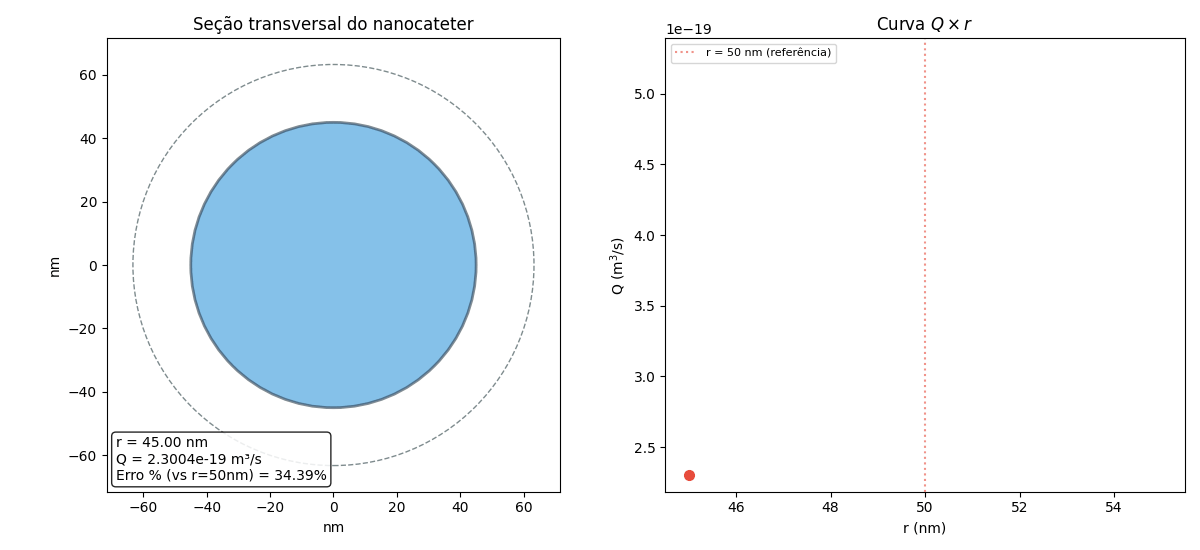

In [18]:
#  Hagen–Poiseuille
Q_ref = vazao_hagen_poiseuille(r, dp, mu, L)

# variação do raio
N_QUADROS = 50
raios_nm = np.linspace(45, 55, N_QUADROS)
raios_m = raios_nm * 1e-9

Q_todos = vazao_hagen_poiseuille(raios_m, dp, mu, L)
erro_percentual_todos = 100 * np.abs(Q_todos - Q_ref) / Q_ref

fig, (ax_secao, ax_curva) = plt.subplots(1, 2, figsize=(12, 5.5))

# seção transversal do canal
raio_max_nm = raios_nm.max()
ax_secao.set_xlim(-raio_max_nm * 1.3, raio_max_nm * 1.3)
ax_secao.set_ylim(-raio_max_nm * 1.3, raio_max_nm * 1.3)
ax_secao.set_aspect("equal")
ax_secao.set_title("Seção transversal do nanocateter")
ax_secao.set_xlabel("nm")
ax_secao.set_ylabel("nm")

circulo_parede = patches.Circle((0, 0), raio_max_nm * 1.15, fill=False, edgecolor="#7f8c8d", linewidth=1, linestyle="--")
ax_secao.add_patch(circulo_parede)
circulo_fluido = patches.Circle((0, 0), raios_nm[0], facecolor="#3498db", alpha=0.6, edgecolor="#2c3e50", linewidth=2)
ax_secao.add_patch(circulo_fluido)

texto_info = ax_secao.text(0.02, 0.02, "", transform=ax_secao.transAxes, fontsize=10, va="bottom", ha="left", bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

# curva Q x r
ax_curva.set_xlim(raios_nm.min() - 0.5, raios_nm.max() + 0.5)
ax_curva.set_ylim(Q_todos.min() * 0.95, Q_todos.max() * 1.05)
ax_curva.set_xlabel("r (nm)")
ax_curva.set_ylabel(r"Q (m$^3$/s)")
ax_curva.set_title(r"Curva $Q \times r$")
ax_curva.axvline(50, color="#e74c3c", linestyle=":", alpha=0.6, label="r = 50 nm (referência)")
ax_curva.legend(fontsize=8, loc="upper left")

linha_curva, = ax_curva.plot([], [], color="#2ecc71", linewidth=2)
ponto_atual, = ax_curva.plot([], [], marker="o", color="#e74c3c", markersize=7)

plt.tight_layout()


def atualizar(frame):
    r_atual_nm = raios_nm[frame]
    Q_atual = Q_todos[frame]
    erro_atual = erro_percentual_todos[frame]

    # seção transversal
    circulo_fluido.set_radius(r_atual_nm)

    texto_info.set_text(
        f"r = {r_atual_nm:.2f} nm\n"
        f"Q = {Q_atual:.4e} m³/s\n"
        f"Erro % (vs r=50nm) = {erro_atual:.2f}%"
    )

    # curva construída progressivamente
    linha_curva.set_data(raios_nm[:frame+1], Q_todos[:frame+1])
    ponto_atual.set_data([r_atual_nm], [Q_atual])

    return circulo_fluido, texto_info, linha_curva, ponto_atual

anim = FuncAnimation(fig, atualizar, frames=N_QUADROS, interval=120, blit=False)

anim.save("gif_nanocateter.gif", writer=PillowWriter(fps=8))
plt.close()
Image(filename="gif_nanocateter.gif")

#**Conclusão**

Durante a execução desta atividade, a dupla pôde praticar os conceitos aprendidos em sala de aula e ter uma primeira experiência com problemas que se aproximam daqueles encontrados em projetos reais. Foi possível perceber a importância de discutir e definir cuidadosamente a abordagem adotada para cálculos numéricos, mesmo em situações aparentemente simples como as estudadas neste trabalho.
Ao longo do projeto, observamos que pequenas diferenças decorrentes de arredondamentos, truncamentos ou limitações de representação numérica podem gerar discrepâncias nos resultados finais. Também foi possível analisar diferentes formas de quantificar essas discrepâncias por meio dos erros absoluto, relativo e percentual, compreendendo melhor como os erros se propagam durante os cálculos.
Outro aspecto interessante foi verificar, na prática, a sensibilidade da equação de vazão em relação ao raio do tubo. Como a vazão é proporcional à quarta potência do raio, pequenas variações nesse parâmetro produziram alterações consideráveis nos resultados, evidenciando a importância da precisão dos dados de entrada.
A parte mais desafiadora deste projeto foi a implementação computacional das soluções. Embora já possuamos alguma experiência com programação, esta foi a primeira oportunidade de aplicar conhecimentos matemáticos de forma mais estruturada em um contexto computacional. Por isso, a atividade foi extremamente relevante para consolidar conceitos teóricos e desenvolver a capacidade de analisar criticamente os resultados obtidos.
Considerando que este foi nosso primeiro projeto na disciplina, acreditamos que o aprendizado alcançado foi significativo. Além de reforçar conceitos de Cálculo Numérico, a atividade nos permitiu compreender melhor a relação entre modelagem matemática, precisão computacional e interpretação dos resultados, conhecimentos que certamente serão importantes nos próximos projetos.